In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from data_preprocessing import load_dataset

dataset_easy = load_dataset("E4_1-1.data")
dataset_medium = load_dataset("E4_2-8.data")
dataset_hard = load_dataset("E4_9-64.data")

In [4]:
from models.CLPTransformer import CLPTransformer

# Parámetros del modelo
blocks_dim = 8
action_dim = 5
placed_dim = 4
d_model = 32
nhead = 4
num_layers = 2
dropout = 0.1

# Crear modelo
model = CLPTransformer(
    block_dim=blocks_dim,
    action_dim=action_dim,
    placed_dim=placed_dim,
    d_model=d_model,
    nhead=nhead,
    num_layers=num_layers,
    dropout=dropout
)

In [5]:
from training import train

epochs = 50
datasets = [dataset_hard, dataset_medium, dataset_easy]
train_size = 7500
train_weights = [1, 1, 1]
test_size = 2500
test_weights = [1, 1, 1]
batch_size = 32
learning_rate = 1e-4
seed = 42

stats = train(model, epochs, datasets, train_size, train_weights, test_size, test_weights, batch_size, learning_rate, seed)

ℹ️ Usando dispositivo: cpu
ℹ️ Iniciando fase: 1/3


KeyboardInterrupt: 

In [6]:
from training import save_model

model_name = "CLPTransformer"
save_model(model, model_name)

✅ Modelo guardado en /home/oscar/CLP-Framework/models/CLPTransformer.pth


In [7]:
from training import load_model

model = load_model(CLPTransformer, model_name)

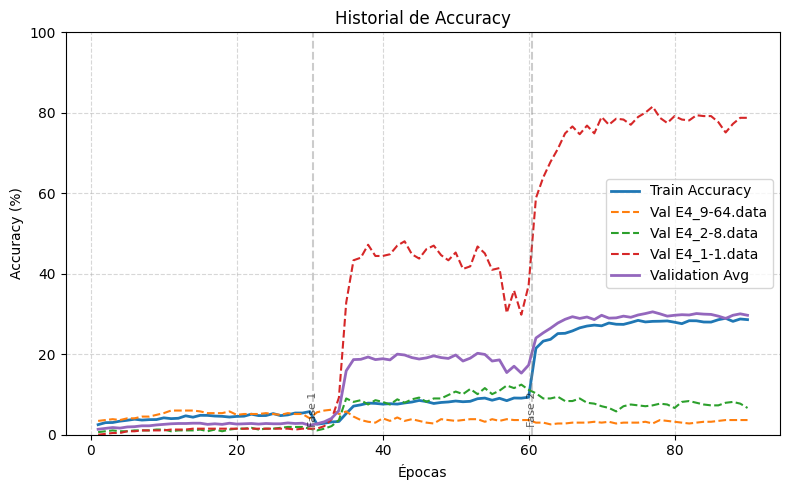

In [8]:
stats.plot()